In [1]:
import re
import numpy as np
import pandas as pd

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from xgboost import XGBRegressor

In [2]:
sample_df = pd.read_csv("../data/sample_5000.csv")
image_features = np.load("../data/image_features.npy")

print(sample_df.shape)
print(image_features.shape)

(5000, 4)
(5000, 1280)


In [3]:
sample_df["catalog_content"] = (
    sample_df["catalog_content"]
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [4]:
def extract_weight(text):
    match = re.search(r"(\d+(\.\d+)?)\s?(kg|g|ml|l)", text.lower())
    if match:
        return float(match.group(1))
    return 0


def extract_pack(text):
    match = re.search(r"pack of (\d+)", text.lower())
    if match:
        return int(match.group(1))
    return 1

In [5]:
sample_df["weight"] = sample_df["catalog_content"].apply(extract_weight)
sample_df["pack_size"] = sample_df["catalog_content"].apply(extract_pack)

structured_features = sample_df[
    ["weight", "pack_size"]
].values

In [6]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,3),
    min_df=2,
    stop_words="english"
)

X_text = vectorizer.fit_transform(sample_df["catalog_content"])

In [7]:
X_multimodal = hstack([
    X_text,
    csr_matrix(image_features)
])

X_full = hstack([
    X_text,
    csr_matrix(image_features),
    csr_matrix(structured_features)
])

In [8]:
y = np.log1p(sample_df["price"])


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [12]:
pred_log = model.predict(X_test)

pred = np.expm1(pred_log)
actual = np.expm1(y_test)

In [17]:
mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
r2 = r2_score(actual, pred)

print("Optimized Model")

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Optimized Model
MAE : 13.860258695602417
RMSE: 33.23992221175778
R²  : 0.09217609992124287


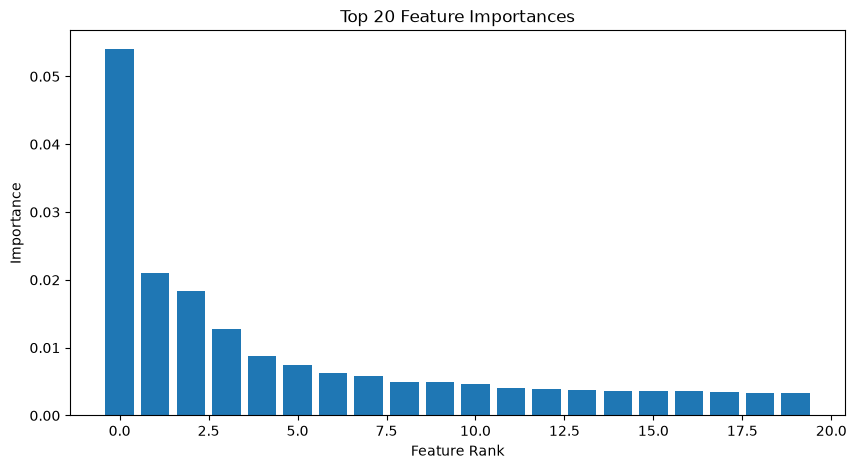

In [16]:
import matplotlib.pyplot as plt
import numpy as np

top = np.sort(importance)[::-1][:20]

plt.figure(figsize=(10,5))
plt.bar(range(len(top)), top)
plt.title("Top 20 Feature Importances")
plt.xlabel("Feature Rank")
plt.ylabel("Importance")
plt.show()


In [15]:
import joblib

joblib.dump(model, "../data/optimized_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
